In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_csv(r"C:\Users\AL HAFIZ COMPUTER\Documents\lab files\eda_manipulate_date_strings_with_python.csv")
df.head()

,date,number_of_strikes,center_point_geom
0,2016-08-05,16,POINT(-101.5 24.7)
1,2016-08-05,16,POINT(-85 34.3)
2,2016-08-05,16,POINT(-89 41.4)
3,2016-08-05,16,POINT(-89.8 30.7)
4,2016-08-05,16,POINT(-86.2 37.9)


In [4]:
#                                           creat new dataset from orignal data of  50,000 rows in csv file
                                        #=====================================================================



In [5]:
# Step 1: Check original dataset size

df.size

31437009

In [6]:
df.shape


(10479003, 3)

In [7]:
# Step 2: Create a random sample of 50,000 rows

df_small = df.sample(n=50000, random_state=42)

In [8]:
# Step 3: Verify the new dataset size

df_small.shape

(50000, 3)

In [9]:
# Step 4: Save the 50,000-row sample as a new CSV file

df_small.to_csv("sample_50000_rows.csv", index=False)

In [10]:
# Step 5: Load the new CSV file

df = pd.read_csv("sample_50000_rows.csv")
df.head() 

,date,number_of_strikes,center_point_geom
0,2018-09-02,2,POINT(-97 28.4)
1,2018-08-14,1,POINT(-109.3 28.3)
2,2017-05-26,1,POINT(-91.7 46.8)
3,2017-03-12,52,POINT(-102.6 32)
4,2018-08-15,27,POINT(-112.4 31.3)


In [11]:
#   check info of new data to see the date Dtype

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               50000 non-null  object
 1   number_of_strikes  50000 non-null  int64 
 2   center_point_geom  50000 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [12]:
# Convert the `date` column to datetime

df["date"] = pd.to_datetime(df["date"])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               50000 non-null  datetime64[ns]
 1   number_of_strikes  50000 non-null  int64         
 2   center_point_geom  50000 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.1+ MB


In [14]:
# Create four new columns.
df['week'] = df['date'].dt.strftime('%Y-W%V')
df['month'] = df['date'].dt.strftime('%Y-%m')
df['quarter'] = df['date'].dt.to_period('Q').dt.strftime('%Y-Q%q')
df['year'] = df['date'].dt.strftime('%Y')

In [15]:
df.head(10)

,date,number_of_strikes,center_point_geom,week,month,quarter,year
0,2018-09-02,2,POINT(-97 28.4),2018-W35,2018-09,2018-Q3,2018
1,2018-08-14,1,POINT(-109.3 28.3),2018-W33,2018-08,2018-Q3,2018
2,2017-05-26,1,POINT(-91.7 46.8),2017-W21,2017-05,2017-Q2,2017
3,2017-03-12,52,POINT(-102.6 32),2017-W10,2017-03,2017-Q1,2017
4,2018-08-15,27,POINT(-112.4 31.3),2018-W33,2018-08,2018-Q3,2018
5,2017-07-29,10,POINT(-102.9 37.9),2017-W30,2017-07,2017-Q3,2017
6,2016-10-01,5,POINT(-67.3 38.2),2016-W39,2016-10,2016-Q4,2016
7,2017-07-30,1,POINT(-81.6 26.9),2017-W30,2017-07,2017-Q3,2017
8,2017-10-11,4,POINT(-96.7 24.1),2017-W41,2017-10,2017-Q4,2017
9,2017-07-18,6,POINT(-81.8 22.6),2017-W29,2017-07,2017-Q3,2017


In [16]:
#                                       Plot the number of weekly lightning strikes in 2018
#                             =======================================================================

In [17]:
# Create a new dataframe view of just 2018 data, summed by week.
df_by_week_2018 = (
    df[df['year'] == '2018']
    .groupby(['week'])
    .sum(numeric_only=True)
    .reset_index()
)

df_by_week_2018.head()

# NOTE: In pandas v.2.X+ you must set 'numeric_only=True' in the sum() function or else it will throw an error

,week,number_of_strikes
0,2018-W01,110
1,2018-W02,1534
2,2018-W03,103
3,2018-W04,1280
4,2018-W05,203


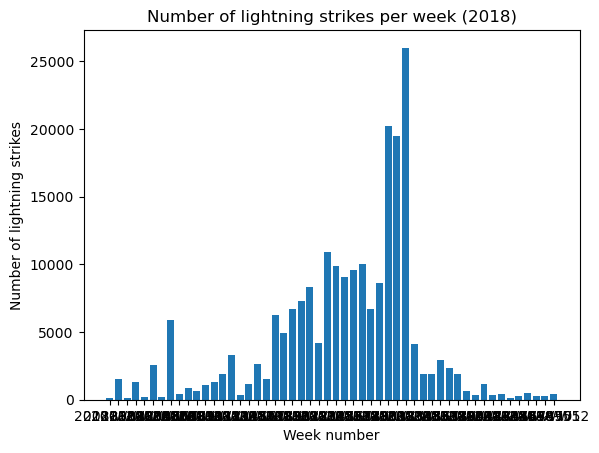

In [18]:
# Plot a bar graph of weekly strike totals in 2018.
plt.bar(x = df_by_week_2018['week'], height = df_by_week_2018['number_of_strikes'])

plt.xlabel("Week number")
plt.ylabel("Number of lightning strikes")
plt.title("Number of lightning strikes per week (2018)")
plt.show()

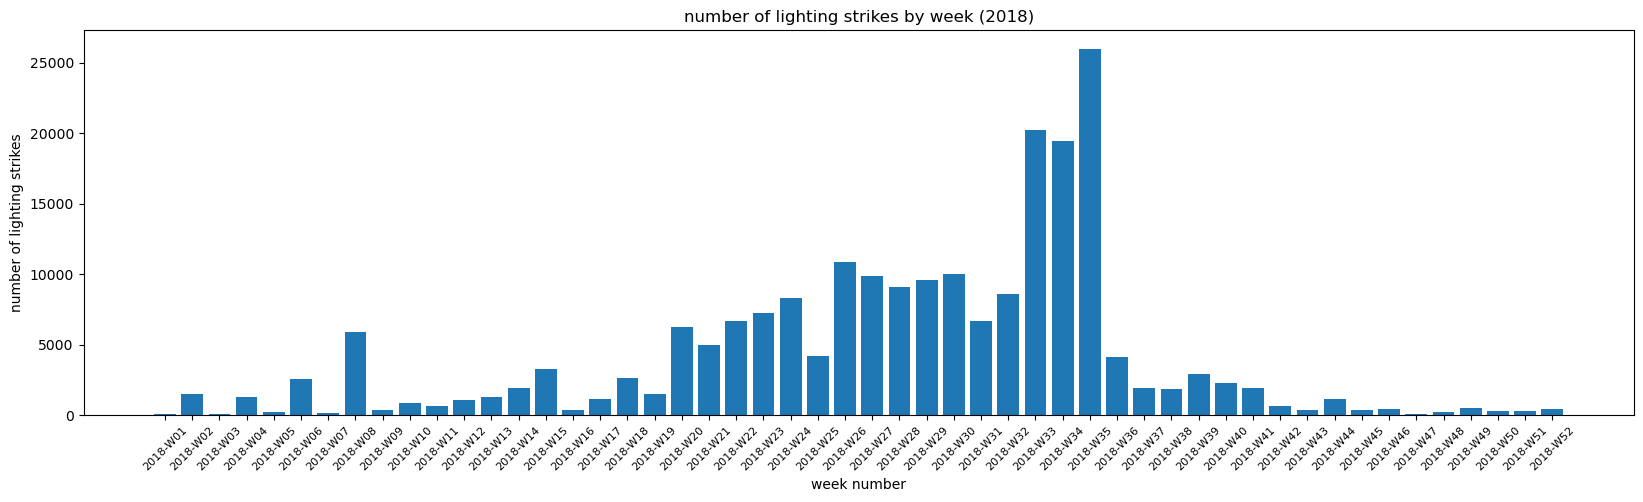

In [19]:
# Adjust the graph size

plt.figure(figsize=(20,5)) # Increase output size.
plt.bar(x= df_by_week_2018["week"],height = df_by_week_2018["number_of_strikes"])

plt.xlabel("week number")
plt.ylabel("number of lighting strikes")
plt.title("number of lighting strikes by week (2018)")
plt.xticks(rotation = 45,fontsize = 8)  # Rotate x-axis labels and decrease font size.
plt.show()

In [20]:
#                              Plot the number of quarterly lightning strikes from 2016–2018
                        #==============================================================================


In [21]:
df_by_quarter = df['number_of_strikes'].div(1000000)
df_by_quarter.head()

0    0.000002
1    0.000001
2    0.000001
3    0.000052
4    0.000027
Name: number_of_strikes, dtype: float64

In [28]:
# Group 2016-2018 data by quarter and sum

df_by_quarter = (
    df.groupby('quarter')['number_of_strikes']
      .sum()
      .reset_index()
)
df_by_quarter = df.groupby('quarter').sum(numeric_only=True).reset_index()
df_by_quarter['number_of_strikes_formatted'] = df_by_quarter['number_of_strikes'].div(1000).round(1).astype(str) + 'K'

df_by_quarter.head()

,quarter,number_of_strikes,number_of_strikes_formatted
0,2016-Q1,12443,12.4K
1,2016-Q2,67994,68.0K
2,2016-Q3,106046,106.0K
3,2016-Q4,9534,9.5K
4,2017-Q1,13140,13.1K


In [29]:
#  Add labels

In [30]:
def addlabels(x, y, labels):
    '''
    Iterates over data and plots text labels above each bar of bar graph.
    '''
    for i in range(len(x)):
        plt.text(i, y[i], labels[i], ha = 'center', va = 'bottom')

In [31]:
# Plot the bar graph

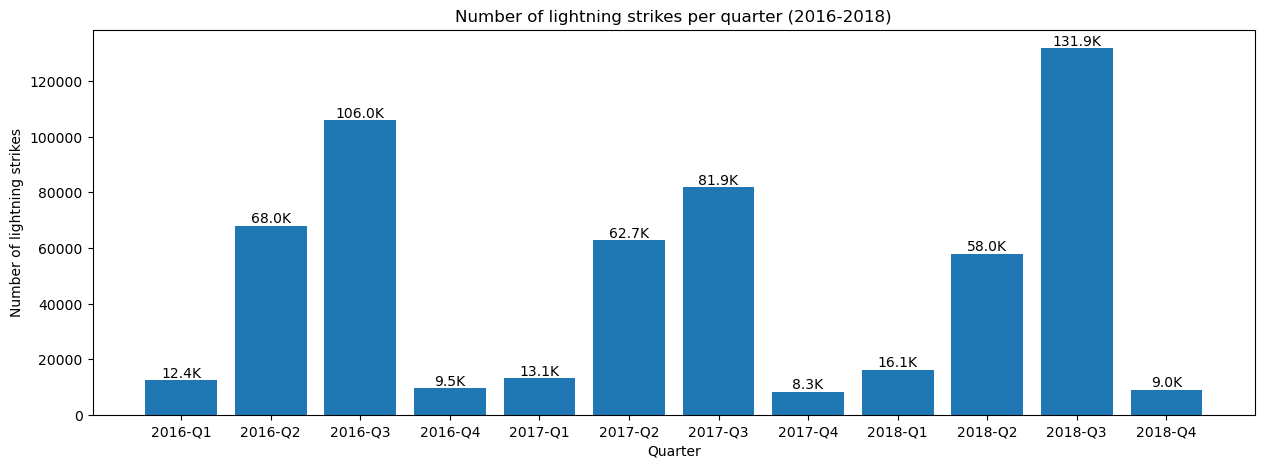

In [32]:
plt.figure(figsize = (15, 5))
plt.bar(x = df_by_quarter['quarter'], height = df_by_quarter['number_of_strikes'])
addlabels(df_by_quarter['quarter'], df_by_quarter['number_of_strikes'], df_by_quarter['number_of_strikes_formatted'])
plt.plot()
plt.xlabel('Quarter')
plt.ylabel('Number of lightning strikes')
plt.title('Number of lightning strikes per quarter (2016-2018)')
plt.show()

In [ ]:
#                                                         Create a grouped bar chart
                                                   #=====================================#

In [33]:
# Create two new columns.
df_by_quarter['quarter_number'] = df_by_quarter['quarter'].str[-2:]
df_by_quarter['year'] = df_by_quarter['quarter'].str[:4]
df_by_quarter.head()

,quarter,number_of_strikes,number_of_strikes_formatted,quarter_number,year
0,2016-Q1,12443,12.4K,Q1,2016
1,2016-Q2,67994,68.0K,Q2,2016
2,2016-Q3,106046,106.0K,Q3,2016
3,2016-Q4,9534,9.5K,Q4,2016
4,2017-Q1,13140,13.1K,Q1,2017


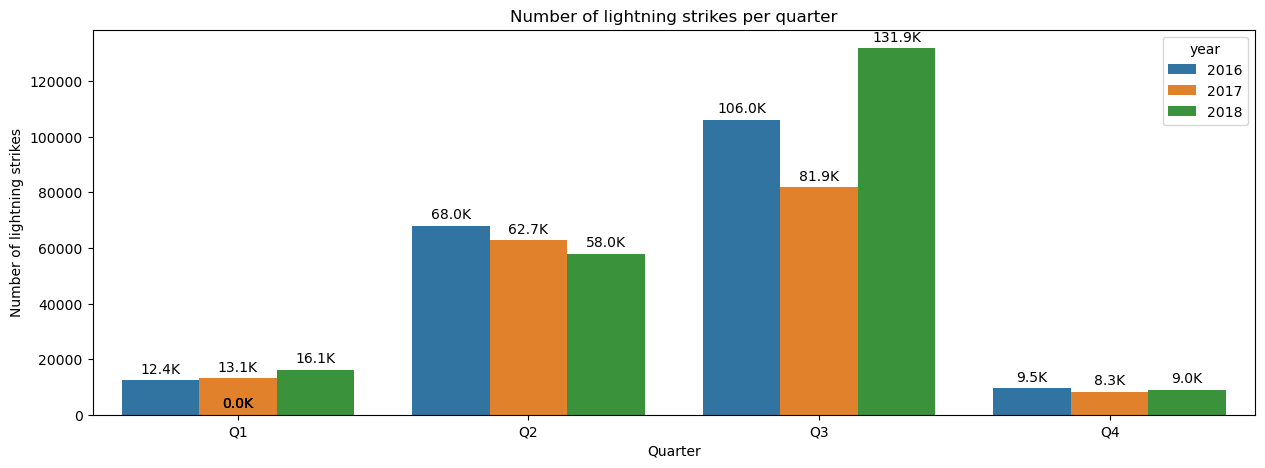

In [34]:
# Fill in the chart parameters
plt.figure(figsize=(15,5))

p = sns.barplot(
    data=df_by_quarter,
    x='quarter_number',
    y='number_of_strikes',
    hue='year'
)

for b in p.patches:
    p.annotate(
        str(round(b.get_height()/1000, 1)) + 'K',
        (b.get_x() + b.get_width()/2., b.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.xlabel("Quarter")
plt.ylabel("Number of lightning strikes")
plt.title("Number of lightning strikes per quarter")
plt.show()


